In [1]:
%reload_ext autoreload
%autoreload 2

In [163]:
import numpy as np
import pandas as pd
import mat73 as mt
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d
from scipy import stats

from fppnpx.preprocessing import read_session, load_waveforms, read_bin
from fppnpx.ChannelSignal import ChannelSignal
from fppnpx.plottools import MATMAP, WAVEMAP_PAL2, MISC6_PAL
from fppnpx.filters import gen_filter
from fppnpx.spectral import multitaper_spectrum, multitaper_spectrogram, spectrum_trunc, spectrum_interp

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [ ]:
# imecpath = Path('/home/mateoumaguing/Documents/MiscData/TibsCFD/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0')
imecpath = "/Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0"

time_window = [204,209]
npxsession = read_session(time_window=time_window, imec_path=imecpath)

Loading session from /Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0
Reading metadata...
Reading channel information...
383 usable channels detected. Use `channel_map` to view usable channels.
Reading cluster information from kilosort...
Session loading complete.


In [100]:
waveformpath = "/Users/mateouma/Downloads/monkey datasets/20230630_DLPFCwaveforms.mat"
waveform_dataset, waveform_means = load_waveforms(waveformpath, npxsession)

Loading waveforms...
138 clusters with good waveforms detected.


In [ ]:
tw = 3.5
n_taps = 2*tw - 1
fs = 30000

ch163 = ChannelSignal(163, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=None, time_halfbandwidth_product=tw, verbose=True)

Loading AP signal from channel 163...
Selecting good units...
Reading in time-series...
Notch filtering...
Computing multitapered spectrum...


(300.0, 5000.0)

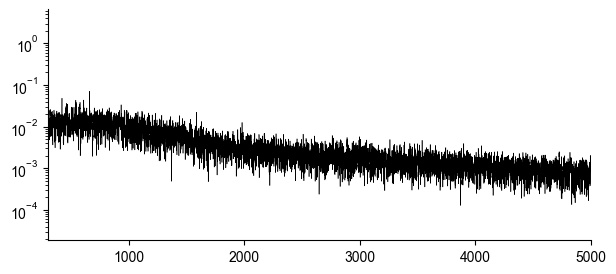

In [102]:
fig,ax = plt.subplots(figsize=(7,3))
ax.semilogy(ch163.mtap_frequencies, ch163.mtap_spectrum, color='k', linewidth=0.4)
ax.set_xlim(300,5e3)

## WaveMAP

In [5]:
from fppnpx.unit_clustering import WaveMAP

In [6]:
# wmc = WaveMAP(random_state=42, resolution=1.5)
wmc = WaveMAP(random_state=99, resolution=1.0, cluster_palette=WAVEMAP_PAL2)
wmc.fit(waveforms=waveform_means, verbose=True)

Computing UMAP: 15 neighbors | 0.1 minimum distance | random_state 99


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Applying Louvain method: 1.0 resolution


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


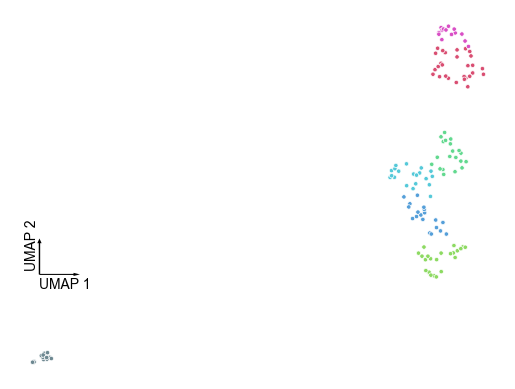

In [7]:
fig,ax = plt.subplots()
wmc.plot_umap(show_clustering_solution=True, ax=ax)

In [36]:
cluster_ids = np.array(list(waveform_dataset.keys()))
cluster_ids

array([ 17,  21,  22,  24,  35,  41,  48,  52,  64,  65,  80,  87,  91,
        95, 105, 116, 117, 123, 125, 129, 130, 135, 139, 140, 146, 150,
       153, 177, 213, 215, 227, 234, 239, 241, 247, 248, 249, 250, 251,
       255, 257, 260, 263, 265, 268, 269, 272, 274, 275, 278, 284, 286,
       287, 291, 292, 296, 298, 306, 310, 311, 313, 314, 315, 317, 322,
       323, 328, 329, 332, 333, 335, 336, 339, 340, 344, 346, 347, 348,
       350, 354, 356, 360, 362, 365, 374, 375, 378, 379, 380, 383, 389,
       392, 393, 396, 397, 398, 401, 403, 405, 410, 417, 418, 419, 423,
       429, 433, 435, 439, 441, 443, 447, 449, 469, 470, 473, 480, 491,
       496, 500, 502, 516, 519, 523, 526, 528, 530, 531, 539, 548, 552,
       554, 556, 557, 561, 572, 583, 585, 587])

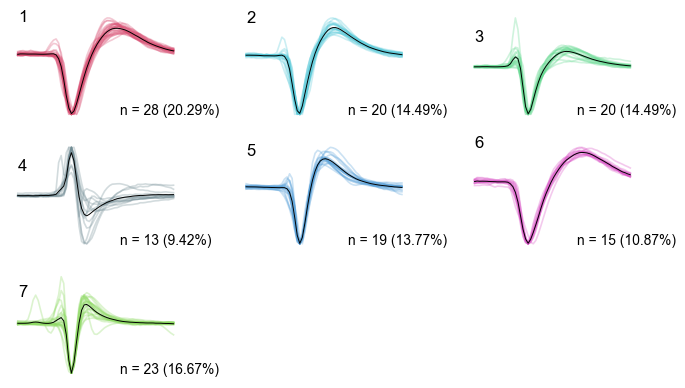

In [17]:
waveform_group_fig = wmc.plot_groups()

In [32]:
cluster_filters = []

for clust in np.unique(wmc.clustering_solution):
    cluster_mean_wf = np.mean(wmc.waveforms[wmc.clustering_solution == clust], axis=0)
    cluster_filters.append(gen_filter(cluster_mean_wf, n=30000, fs=30000, center=True))

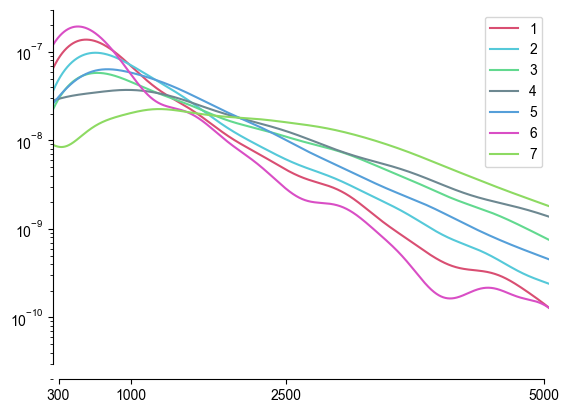

In [70]:
cluster_idx_unit_list = []

fig,ax = plt.subplots()
for clust in np.unique(wmc.clustering_solution):
    wmc_clust_sol_idx = np.where(np.array(wmc.clustering_solution) == clust)[0]
    cluster_idx_unit_list.append(cluster_ids[wmc_clust_sol_idx])
    wmc_cluster_filters = []
    for wm_idx in wmc_clust_sol_idx:
        wf_filter_t,wf_filter_f,wf_filter_psd,freq_axis = gen_filter(wmc.waveforms[wm_idx], n=30000, fs=30000, center=True)
        wmc_cluster_filters.append(wf_filter_psd)
    cluster_filter = np.array(wmc_cluster_filters).mean(axis=0)
    ax.semilogy(freq_axis, cluster_filter, color=wmc.CLUSTER_PALETTE[clust], label=f"{clust+1}")
ax.legend()
ax.set_xlim(250, 5050)
ax.set_xticks([300, 1000, 2500, 5000])
ax.set_ylim((2e-11, 3e-7))
ax.spines['left'].set_bounds(3e-11, 3e-7)
ax.spines['bottom'].set_bounds(300, 5e3)

/var/folders/nm/w2ptffz16jvdj7330zc_2btw0000gp/T/ipykernel_2199/2243036613.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


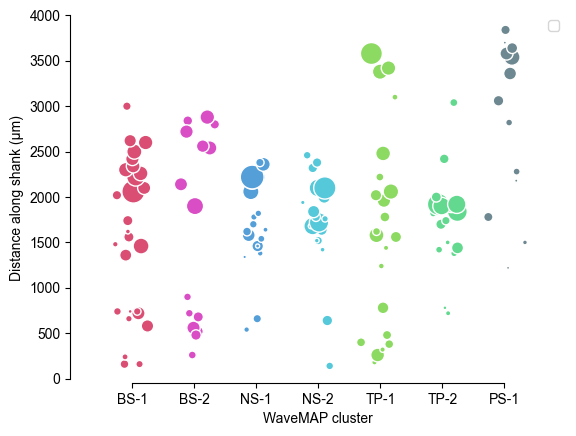

In [88]:
clust_order = [0, 3, 5, 6, 2, 1, 4]

fig,ax = plt.subplots()

for clust in np.unique(wmc.clustering_solution):
    cluster_unit_ids = cluster_idx_unit_list[clust]

    wmc_cluster_info = npxsession['cluster_info'][np.isin(npxsession['cluster_info']['cluster_id'],cluster_unit_ids)]
    ax.scatter(np.random.randn(len(cluster_unit_ids))/8 + clust_order[clust], wmc_cluster_info['depth'], color=wmc.CLUSTER_PALETTE[clust], s=wmc_cluster_info['fr']*7.5, edgecolor='white')
ax.set_ylim((-45.0, 4025.0))
ax.set_xlim((-1, 7))
ax.set_xlabel("WaveMAP cluster")
ax.set_ylabel("Distance along shank (µm)")
ax.spines['bottom'].set_bounds(0, 6)
ax.spines['left'].set_bounds(0, 4000)
ax.set_xticks([0,1,2,3,4,5,6])
ax.set_xticklabels(['BS-1', 'BS-2', 'NS-1', 'NS-2', 'TP-1', 'TP-2', 'PS-1'])
ax.legend()

## Spike waveform filters explains signal spectra

In [187]:
def plot_filter_superposition(channel_signal, unit_list, mode='isolated', truncate_idx=62):
    # indices for convolve windows
    filter_add_length = truncate_idx - 20
    end_idx = -(filter_add_length - 1)

    # make isolated spike time series
    spikes_conv_list = []
    spikes_mask_list = []

    for i,unit in enumerate(unit_list):
        unit_spike_train = np.zeros_like(channel_signal.time_series)
        unit_spike_train[npxsession['cluster_spike_times'][unit]] = 1
        unit_spikes_conv = np.convolve(unit_spike_train, waveform_dataset[unit]['time_filter'][:truncate_idx])[20:end_idx]
        spikes_mask_list.append(unit_spikes_conv == 0)
        spikes_conv_list.append(unit_spikes_conv)

    if mode == 'isolated':
        total_time_series = np.sum(np.array(spikes_conv_list), axis=0)
    elif mode == 'raw':
        total_time_series = channel_signal.time_series

    # calculate spectrum of time series
    mt_PSD,mt_freqs = multitaper_spectrum(total_time_series, fs=fs, time_halfbandwidth_product=tw, start_time=time_window[0])

    # theoretical spectra
    theoretical_freq_axis = waveform_dataset[unit_list[0]]['filter_freq_axis']
    theoretical_spectrum_list = []
    for unit in unit_list:
        unit_theoretical_spectrum = waveform_dataset[unit]['filter_spectrum'] * waveform_dataset[unit]['firing_rate']
        theoretical_spectrum_list.append(unit_theoretical_spectrum)
    theoretical_spectrum = np.sum(np.array(theoretical_spectrum_list), axis=0)

    # QQ plots
    freq_range = (300,5000)

    mt_PSD_trunc,mt_freqs_trunc = spectrum_trunc(mt_freqs,mt_PSD,freq_range)
    theor_spk_PSD_trunc,theor_freqs_trunc = spectrum_trunc(theoretical_freq_axis, theoretical_spectrum,freq_range)

    theor_spk_PSD_interp = spectrum_interp(mt_freqs_trunc, theor_freqs_trunc, theor_spk_PSD_trunc)

    Z_f = np.sort((n_taps * mt_PSD_trunc) / theor_spk_PSD_interp)
    n = Z_f.size

    theor_quantiles = stats.gamma.ppf((np.arange(1, n + 1) - 0.5) / n, a=n_taps)

    # QQ (300 - 1000 Hz)
    freq_range2 = (300,1000)

    mt_PSD_trunc2,mt_freqs_trunc2 = spectrum_trunc(mt_freqs,mt_PSD,freq_range2)
    theor_spk_PSD_trunc2,theor_freqs_trunc2 = spectrum_trunc(theoretical_freq_axis,theoretical_spectrum,freq_range2)
    theor_spk_PSD_interp2 = spectrum_interp(mt_freqs_trunc2, theor_freqs_trunc2, theor_spk_PSD_trunc2)

    Z_f2 = np.sort((n_taps * mt_PSD_trunc2) / theor_spk_PSD_interp2)
    n2 = Z_f2.size

    theor_quantiles_2 = stats.gamma.ppf((np.arange(1, n2 + 1) - 0.5) / n2, a=n_taps)

    gridspec = {'width_ratios': [1, 1, 0.4, 0.4]}
    fig, ax = plt.subplots(1,4, figsize=(10,2), gridspec_kw=gridspec)

    # time series
    ax[0].plot(channel_signal.time_axis, total_time_series, color='k', linewidth=0.8)
    for i,unit in enumerate(unit_list):
        time_series_excerpt = total_time_series.copy()
        time_series_excerpt[spikes_mask_list[i]] = np.nan
        ax[0].plot(channel_signal.time_axis, time_series_excerpt, color=MISC6_PAL[i], linewidth=0.8)
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Voltage (mV)")
    ax[0].set_xlim((203.5, 209.5))
    ax[0].set_xticks([204,206,208,209])
    ax[0].set_xticklabels([204,206,208,''])
    ax[0].set_yticks([-125, 0, 125])
    ax[0].set_ylim((-150, 150))
    ax[0].spines['bottom'].set_bounds(204, 209)
    ax[0].spines['left'].set_bounds(-125, 125)

    # spectrum
    ax[1].semilogy(mt_freqs, mt_PSD, color='k', linewidth=0.6)
    for i,unit in enumerate(unit_list):
        ax[1].semilogy(theoretical_freq_axis, theoretical_spectrum_list[i], color=MISC6_PAL[i], linewidth=2)
    ax[1].set_xlim(250, 5050)
    ax[1].set_ylim(6e-9, 1)
    ax[1].set_xticks([300, 1000, 2500, 5000])
    ax[1].set_yticks([1e-8,1e-6,1e-4,1e-2,1])
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_ylabel("Log Power")
    ax[1].spines['left'].set_bounds(1e-8, 1)
    ax[1].spines['bottom'].set_bounds(300, 5e3)

    # QQ
    ax[2].scatter(theor_quantiles, Z_f, marker='x', c='k', s=1)
    ax[2].plot(np.arange(-100,100), np.arange(-100,100), color='red', linewidth=0.5)
    ax[2].set_xlim((-1, 21))
    ax[2].set_ylim((-1, 21))
    ax[2].set_xlabel("Theoretical quantiles")
    ax[2].set_ylabel("Sample quantiles")
    ax[2].set_xticks([0,10,20])
    ax[2].spines['bottom'].set_bounds(0, 20)
    ax[2].spines['left'].set_bounds(0, 20)

    # QQ (300 - 1000 Hz)
    ax[3].scatter(theor_quantiles_2, Z_f2, marker='x', c='k', s=1)
    ax[3].plot(np.arange(-100,100), np.arange(-100,100), color='red', linewidth=0.5)
    ax[3].set_xlim((-1, 21))
    ax[3].set_ylim((-1, 21))
    ax[3].set_xlabel("Theoretical quantiles\n (300-1000 Hz)")
    ax[3].set_ylabel("Sample quantiles\n (300-1000 Hz)")
    ax[3].set_xticks([0,10,20])
    ax[3].spines['bottom'].set_bounds(0, 20)
    ax[3].spines['left'].set_bounds(0, 20)

    fig.tight_layout()

    return fig

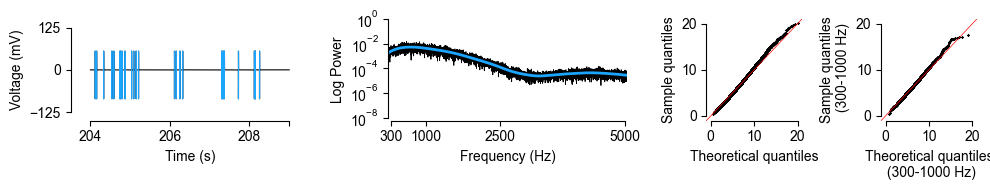

In [188]:
filt_superpos_fig = plot_filter_superposition(ch163, [296], mode='isolated')

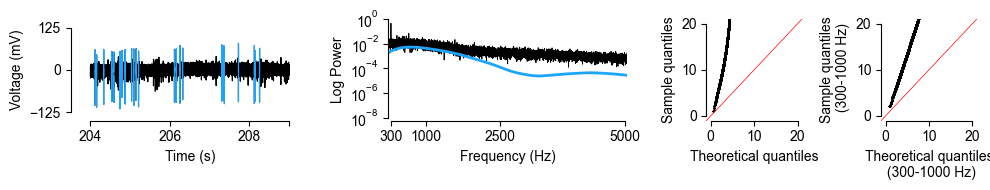

In [189]:
filt_superpos_fig = plot_filter_superposition(ch163, [296], mode='raw')

In [184]:
ch208 = ChannelSignal(208, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=None, time_halfbandwidth_product=tw, verbose=True)

Loading AP signal from channel 208...
Selecting good units...
Reading in time-series...
Notch filtering...
Computing multitapered spectrum...


In [194]:
npxsession['clusters_on_channels'][208]

array([372, 373, 374, 375, 376, 377, 378, 379, 380, 383, 385], dtype=int32)

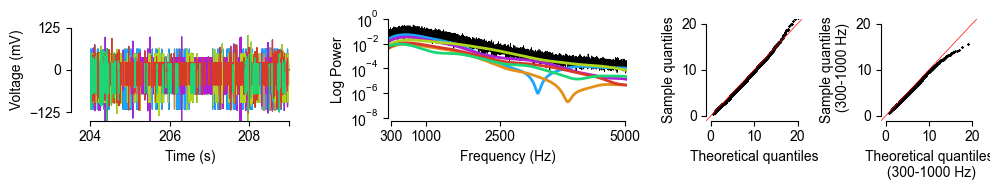

In [190]:
filt_superpos_fig = plot_filter_superposition(ch208, [378, 379, 374, 375, 380, 383], mode='isolated')

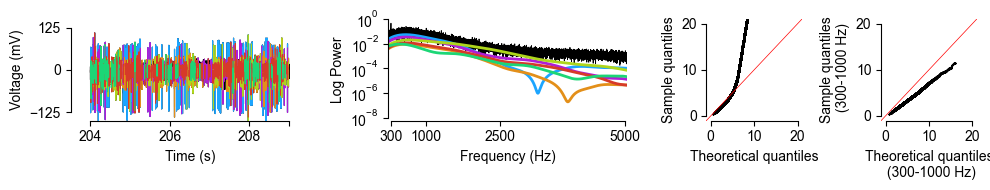

In [191]:
filt_superpos_fig = plot_filter_superposition(ch208, [378, 379, 374, 375, 380, 383], mode='raw')